In [6]:
import sys
# Add the directory containing your file to the system path
sys.path.insert(1, '/kaggle/input/datasets/naynoona/helpers')

In [7]:
import helpers
import numpy as np
import os
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
import torch
from sklearn.metrics import classification_report
import json
from sklearn.preprocessing import MinMaxScaler

### Using MinMax scaler
### No clipping
### test:30% val:15%
### batch_size=20
### criterion weights = [0.3, 1.0, 1.0, 1.0, 1.0, 1.0]
### Cosine Annealing scheduler starting from 1e-3 till 1e-6
### Epochs: 75

In [8]:
# I will simply load the entire dataset into a data loader (for batch processing)
train_dataset_path = r"/kaggle/input/datasets/naynoona/cmr-multi/CMR-MULTI/CINE_MULTI/2CH_TR/image"
mask_dataset_path = r"/kaggle/input/datasets/naynoona/cmr-multi/CMR-MULTI/CINE_MULTI/2CH_TR/anno"


test_data_percentage, val_data_percentage = 0.3, 0.15
mri_dataset, val_mri_dataset, test_mri_dataset = helpers.create_2d_dataset(train_dataset_path, mask_dataset_path, scaler=MinMaxScaler(), clip=False, test_data_percentage=test_data_percentage, val_data_percentage=val_data_percentage)


batch_size = 20
mri_dataloader = DataLoader(mri_dataset, batch_size=batch_size)
test_mri_dataloader = DataLoader(test_mri_dataset, batch_size=batch_size)
val_mri_dataloader  = DataLoader(val_mri_dataset, batch_size=batch_size)

classes = list(helpers.load_labels(Problem_Type="CINE", Image_Type="2CH").keys())
print(len(classes))
print(classes)

All dataset is of length torch.Size([8550, 1, 141, 131]) 
With Masks of torch.Size([8550, 1, 141, 131])
Splitting — train: 4703  val: 1282  test: 2565
3
[0, 1, 2]


In [9]:
class FCN(nn.Module):
    def __init__(self, in_channels, num_classes):
        """
        FCN with learned transposed convolution upsampling.
        Each decoder stage: ConvTranspose2d (upsample ×2) → Conv2d (refine)
        """
        super(FCN, self).__init__()

        # ── Encoder ──────────────────────────────────────────────────────────
        self.conv1_1 = nn.Conv2d(in_channels, 32,  kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(32,          32,  kernel_size=3, padding=1)
        self.pool1   = nn.MaxPool2d(2, 2)                               # H/2

        self.conv2_1 = nn.Conv2d(32,  64, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(64,  64, kernel_size=3, padding=1)
        self.pool2   = nn.MaxPool2d(2, 2)                               # H/4

        self.conv3_1 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool3   = nn.MaxPool2d(2, 2)                               # H/8

        # ── Bottleneck ───────────────────────────────────────────────────────
        self.conv4_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)

        # ── Decoder stage 1: H/8 → H/4 ──────────────────────────────────────
        # ConvTranspose doubles spatial size; +128 because we concat skip_8x
        self.up1     = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec1_1  = nn.Conv2d(128 + 128, 128, kernel_size=3, padding=1)
        self.dec1_2  = nn.Conv2d(128,       128, kernel_size=3, padding=1)

        # ── Decoder stage 2: H/4 → H/2 ──────────────────────────────────────
        # +64 because we concat skip_4x
        self.up2     = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2_1  = nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1)
        self.dec2_2  = nn.Conv2d(64,      64, kernel_size=3, padding=1)

        # ── Decoder stage 3: H/2 → H ─────────────────────────────────────────
        # No skip here (pool1 features are very shallow, marginal benefit)
        self.up3     = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec3_1  = nn.Conv2d(32, 32, kernel_size=3, padding=1)

        # ── Final classifier head ─────────────────────────────────────────────
        self.classifier = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        orig_size = x.shape[2:]

        # ── Encoder ──────────────────────────────────────────────────────────
        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = self.pool1(x)                   # H/2

        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        skip_4x = x                         # save /4 features for skip
        x = self.pool2(x)                   # H/4

        x = F.relu(self.conv3_1(x))
        x = F.relu(self.conv3_2(x))
        skip_8x = x                         # save /8 features for skip
        x = self.pool3(x)                   # H/8

        # ── Bottleneck ───────────────────────────────────────────────────────
        x = F.relu(self.conv4_1(x))
        x = F.relu(self.conv4_2(x))

        # ── Decoder ──────────────────────────────────────────────────────────
        # Stage 1: learned upsample + concat skip_8x + refine
        x = self.up1(x)                                        # H/8 → H/4
        x = self._match_and_cat(x, skip_8x)                   # handle odd sizes
        x = F.relu(self.dec1_1(x))
        x = F.relu(self.dec1_2(x))

        # Stage 2: learned upsample + concat skip_4x + refine
        x = self.up2(x)                                        # H/4 → H/2
        x = self._match_and_cat(x, skip_4x)
        x = F.relu(self.dec2_1(x))
        x = F.relu(self.dec2_2(x))

        # Stage 3: learned upsample + refine
        x = self.up3(x)                                        # H/2 → H
        x = F.relu(self.dec3_1(x))

        # Final resize handles any residual off-by-one from odd input dims
        x = F.interpolate(x, size=orig_size, mode='bilinear', align_corners=False)

        return self.classifier(x)           # (N, num_classes, H, W)

    @staticmethod
    def _match_and_cat(upsampled, skip):
        """
        Crop or pad upsampled to match skip's spatial size before concat.
        Needed because ConvTranspose2d on odd dimensions can be off by 1px.
        """
        if upsampled.shape[2:] != skip.shape[2:]:
            upsampled = F.interpolate(upsampled, size=skip.shape[2:],
                                      mode='bilinear', align_corners=False)
        return torch.cat([upsampled, skip], dim=1)
    

hist_fcn = {'train_acc': [], 'train_dice': [], 'train_f1': [], 'val_acc': [], 'val_dice': [], 'val_f1': []}

In [10]:
# ── Helper: run one full pass over a dataloader and return metrics ────────────
 
def run_eval(model, dataloader, device):
    """
    Runs model in eval mode over *all* batches in `dataloader`.
    Returns (dice, accuracy, f1) computed on the full set — not per-batch averages.
    """
    model.eval()
    all_preds   = []
    all_targets = []
 
    with torch.no_grad():
        for data, targets in dataloader:
            data    = data.to(device)
            targets = targets.squeeze(1).long().to(device)
            scores  = model(data)
            preds   = torch.argmax(scores, dim=1)   # (N, H, W)
 
            all_preds.append(preds.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
 
    all_preds   = np.concatenate(all_preds,   axis=0)  # (total_N, H, W)
    all_targets = np.concatenate(all_targets, axis=0)
 
    return helpers.validate(all_targets, all_preds, num_classes=len(classes))
 

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using {device}")

model = FCN(in_channels=1, num_classes=len(classes)).to(device)
print(model)


class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num_classes = logits.shape[1]

        # Convert logits to probabilities over class dimension
        probs = torch.softmax(logits, dim=1)  # (N, C, H, W)

        # One-hot encode targets: (N, H, W) -> (N, C, H, W)
        targets_one_hot = torch.zeros_like(probs)  # (N, C, H, W)
        targets_one_hot.scatter_(1, targets.unsqueeze(1), 1)  # fill class channels

        # Flatten spatial dims, keep class dim: (N, C, H*W)
        probs = probs.view(probs.shape[0], num_classes, -1)
        targets_one_hot = targets_one_hot.view(targets_one_hot.shape[0], num_classes, -1)

        # Compute Dice per class, then average
        intersection = (probs * targets_one_hot).sum(dim=2)  # (N, C)
        dice = (2. * intersection + self.smooth) / (
            probs.sum(dim=2) + targets_one_hot.sum(dim=2) + self.smooth
        )  # (N, C)

        dice = dice[:, 1:]   # ignore class 0
        return 1 - dice.mean()

# Define the loss function
class_weights = torch.tensor([0.3, 1.0, 1.0], dtype=torch.float).to(device)
ce_loss = nn.CrossEntropyLoss(weight=class_weights)


def combined_loss(logits, targets):
    return ce_loss(logits, targets) + DiceLoss()(logits, targets)

criterion = combined_loss


# Define the optimizer plus a learning rate scheduler using cosine annealing
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=75,       # number of epochs until LR reaches eta_min
    eta_min=1e-6    # floor LR — prevents the rate from hitting 0
) #Here, the learning rate starts from 1e-3 and eventually reaches 1e-6 after 75 epochs

num_epochs = 75
for epoch in range(num_epochs):

    # Choose some random batches for validation
    #n_samples_val = int(val_data_percentage * len(mri_dataloader))
    #random_batch_indices = np.random.randint(0, len(mri_dataloader), n_samples_val // batch_size)
    #print(random_batch_indices)

    model.train()
    print(f"Epoch [{epoch + 1}/{num_epochs}]")

    running_loss = 0.0
    total_samples = 0
    train_preds_all = torch.tensor([]).to(device)
    train_targets_all = torch.tensor([]).to(device)

    for batch_index, (data, targets) in enumerate(tqdm(mri_dataloader)):
        data = data.to(device)
        targets = targets.squeeze(1).long().to(device)
        scores = model(data)
        loss = criterion(scores, targets)

        preds = torch.argmax(scores, dim=1)  # (N, H, W)

        # ── Training batch ───────────────────────────────────────────────────
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size     = data.size(0)
        running_loss  += loss.item() * batch_size
        total_samples += batch_size

        # Accumulate predictions for epoch-level training metrics
        train_preds_all = torch.cat((train_preds_all, preds), dim=0).to(device)
        train_targets_all = torch.cat((train_targets_all, targets), dim=0).to(device)

    # ── End-of-epoch training metrics ────────────────────────────────────────
    epoch_loss = running_loss / total_samples
    #print(f"Epoch [{epoch + 1}] Loss: {epoch_loss:.4f}")

    val_dice, val_acc, val_f1 = run_eval(model, val_mri_dataloader, device)
    hist_fcn['val_acc'].append((epoch + 1, val_acc))
    hist_fcn['val_dice'].append((epoch + 1, val_dice))
    hist_fcn['val_f1'].append((epoch + 1, val_f1))

    # Concatenate all training batches: (total_N, H, W)
    train_preds_np   = train_preds_all.to('cpu').numpy()
    train_targets_np = train_targets_all.to('cpu').numpy()

    if(epoch % 10 == 0): #after each 10 epochs, write results so as not to lose them mid-execution
      with open("hist_fcn.json", "w") as f:
        json.dump(hist_fcn, f, indent=4) 

    train_dice, train_acc, train_f1 = helpers.validate(
        train_targets_np,
        train_preds_np,
        num_classes=len(classes)
    )

    hist_fcn['train_acc'].append((epoch + 1, train_acc))
    hist_fcn['train_f1'].append((epoch + 1, train_f1))
    hist_fcn['train_dice'].append((epoch + 1, train_dice))

    print(f"Epoch [{epoch + 1}] Train - dice: {train_dice:.4f}  acc: {train_acc:.4f}  f1: {train_f1:.4f}")




def generate_classification_report(model, dataloader_obj):
    model.eval()
    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for images, labels in dataloader_obj:
            images = images.to(device)
            labels = labels.squeeze(1).long().to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu())
            all_targets.append(labels.cpu())
            #print(torch.unique(preds))

    all_preds   = torch.cat(all_preds).view(-1)
    all_targets = torch.cat(all_targets).view(-1)

    return classification_report(all_targets.numpy(), all_preds.numpy())


using cuda
FCN(
  (conv1_1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1_2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2_1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4_1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4_2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (up1): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
  (dec1_1): Conv2d

100%|██████████| 236/236 [00:23<00:00, 10.00it/s]


Epoch [1] Train - dice: 0.5052  acc: 0.8744  f1: 0.6508
Epoch [2/75]


100%|██████████| 236/236 [00:23<00:00, 10.08it/s]


Epoch [2] Train - dice: 0.6042  acc: 0.8987  f1: 0.7228
Epoch [3/75]


...

Epoch [73] Train - dice: 0.9324  acc: 0.9849  f1: 0.9531
Epoch [74/75]


100%|██████████| 236/236 [00:25<00:00,  9.37it/s]


Epoch [74] Train - dice: 0.9335  acc: 0.9851  f1: 0.9539
Epoch [75/75]


100%|██████████| 236/236 [00:25<00:00,  9.35it/s]


Epoch [75] Train - dice: 0.9333  acc: 0.9850  f1: 0.9538


In [13]:
with open("hist_fcn.json", "w") as f:
    json.dump(hist_fcn, f, indent=4)

In [14]:
test_dice, test_acc, test_f1 = run_eval(model, test_mri_dataloader, device)
print(f"\nTest — dice: {test_dice:.4f}  acc: {test_acc:.4f}  f1: {test_f1:.4f}")

print(generate_classification_report(model, test_mri_dataloader))


Test — dice: 0.7948  acc: 0.9495  f1: 0.8570
              precision    recall  f1-score   support

           0       0.99      0.98      0.98  38781623
           1       0.84      0.91      0.87   4898610
           2       0.73      0.70      0.72   3697882

    accuracy                           0.95  47378115
   macro avg       0.85      0.86      0.86  47378115
weighted avg       0.95      0.95      0.95  47378115



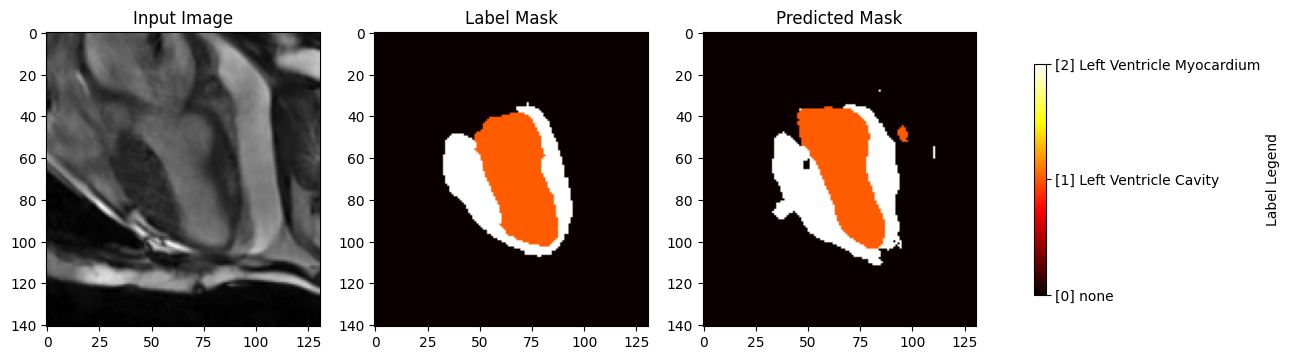

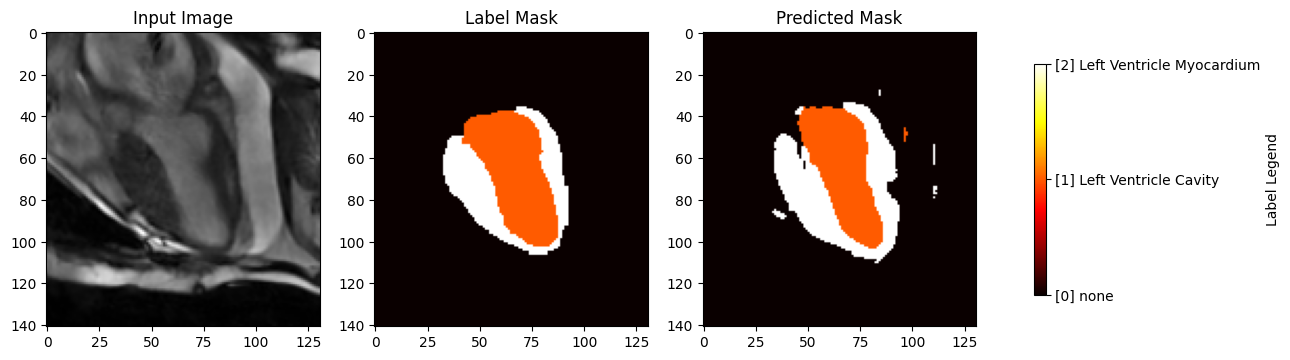

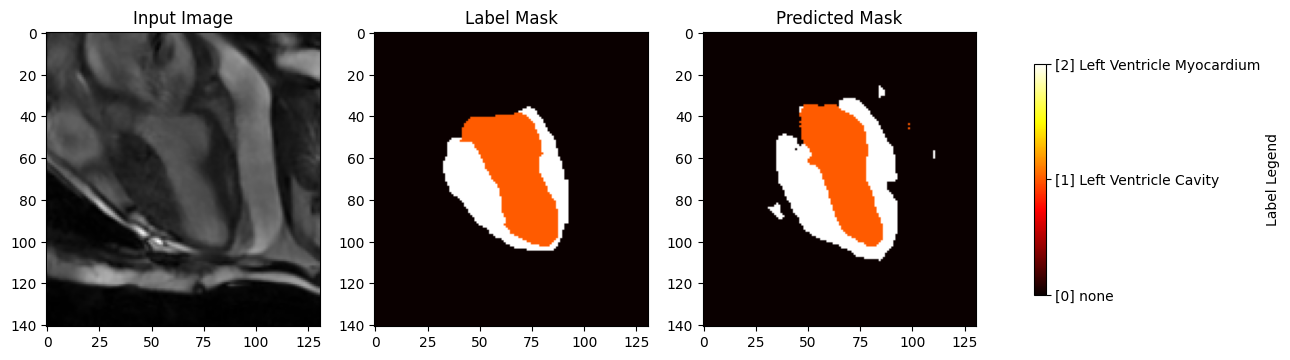

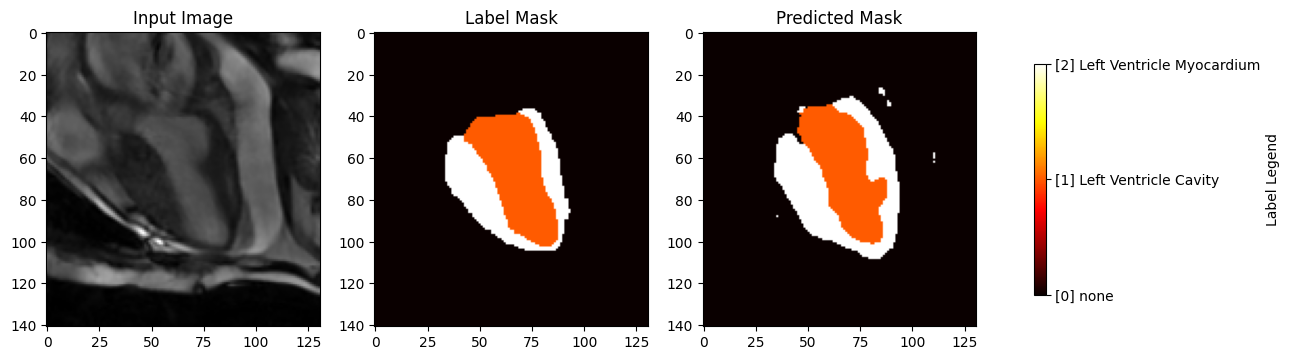

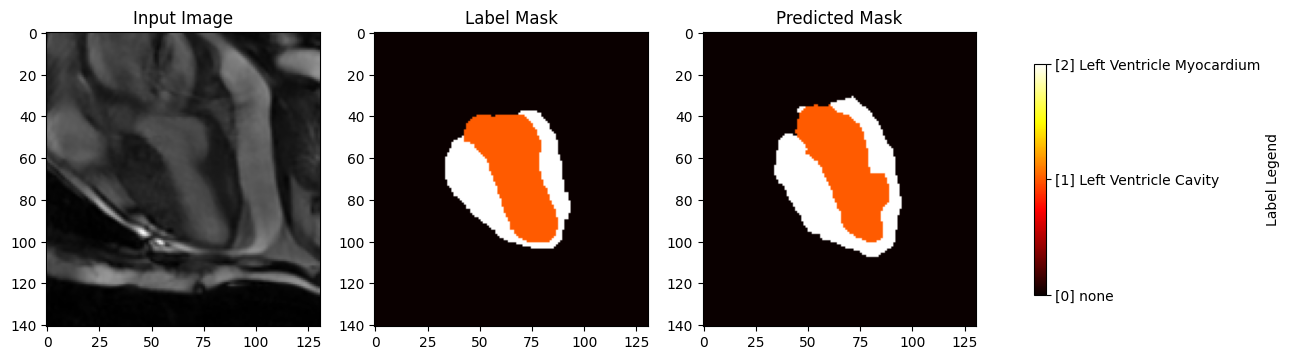

In [15]:
images, masks = next(iter(test_mri_dataloader))

images = images.to(device)
masks = masks.to(device)

masks = masks.squeeze(1).long()

model.eval()
with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)    

images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()


import matplotlib.pyplot as plt

def visualize_sample(img, mask, pred, labels_map):
    figure,axis = plt.subplots(1,3,figsize=(15,10))

    axis[0].imshow(img.squeeze(), cmap='grey')
    axis[0].set_title("Input Image")

    Plot_Color_Op = axis[1].imshow(mask, cmap='hot')
    axis[1].set_title("Label Mask")

    axis[2].imshow(pred, cmap='hot')
    axis[2].set_title("Predicted Mask")

    cbar = figure.colorbar(Plot_Color_Op, ax=axis.ravel().tolist(), shrink=0.3, ticks=list(labels_map.keys()), label='Label Legend')
    cbar.ax.set_yticklabels(list(labels_map.values()))

labelled_classes = helpers.load_labels(Problem_Type="CINE", Image_Type="4CH")
for i in range(5):  # change number as you like
    visualize_sample(images[i], masks[i], preds[i], labelled_classes)



In [16]:
def average_by_epoch(metrics_dict):
    result = {}

    for metric, values in metrics_dict.items():
        epoch_sums = {}
        epoch_counts = {}

        # accumulate sums and counts
        for epoch, score in values:
            if(epoch in epoch_sums.keys()):
                epoch_sums[epoch] += score
                epoch_counts[epoch] += 1
            else:
                epoch_sums[epoch] = score
                epoch_counts[epoch] = 1

        # compute averages
        averaged = []
        for epoch in sorted(epoch_sums.keys()):
            avg = epoch_sums[epoch] / epoch_counts[epoch]
            averaged.append((epoch, avg))

        result[metric] = averaged

    return result


hist_fcn = average_by_epoch(hist_fcn)
with open("hist_fcn.json", "w") as f:
    json.dump(hist_fcn, f, indent=4)




{'train_acc': [(1, 0.8744399174422329), (2, 0.8987347090789335), (3, 0.9081269887031078), (4, 0.9192500446044615), (5, 0.9232533432222336), (6, 0.9301607120127956), (7, 0.9360243381327031), (8, 0.9422014819007073), (9, 0.9470353058629711), (10, 0.9484333286561819), (11, 0.9516544735526423), (12, 0.954144495523973), (13, 0.9576686940500935), (14, 0.9603502685701418), (15, 0.9627885575394329), (16, 0.9644710312628609), (17, 0.9659424518355564), (18, 0.9666956654662745), (19, 0.9688590465980699), (20, 0.9701126452160275), (21, 0.9716510976692027), (22, 0.9725963703577818), (23, 0.9736674875453143), (24, 0.9738475285225947), (25, 0.9748097232211868), (26, 0.9754680815032611), (27, 0.9761690901575109), (28, 0.9762322541499877), (29, 0.9768410320938813), (30, 0.9773242763512504), (31, 0.977632187864057), (32, 0.9771353714639632), (33, 0.9774896976328054), (34, 0.9780021467469111), (35, 0.9784525369793979), (36, 0.9789765437112268), (37, 0.9794139949374181), (38, 0.980004250762869), (39, 0.98

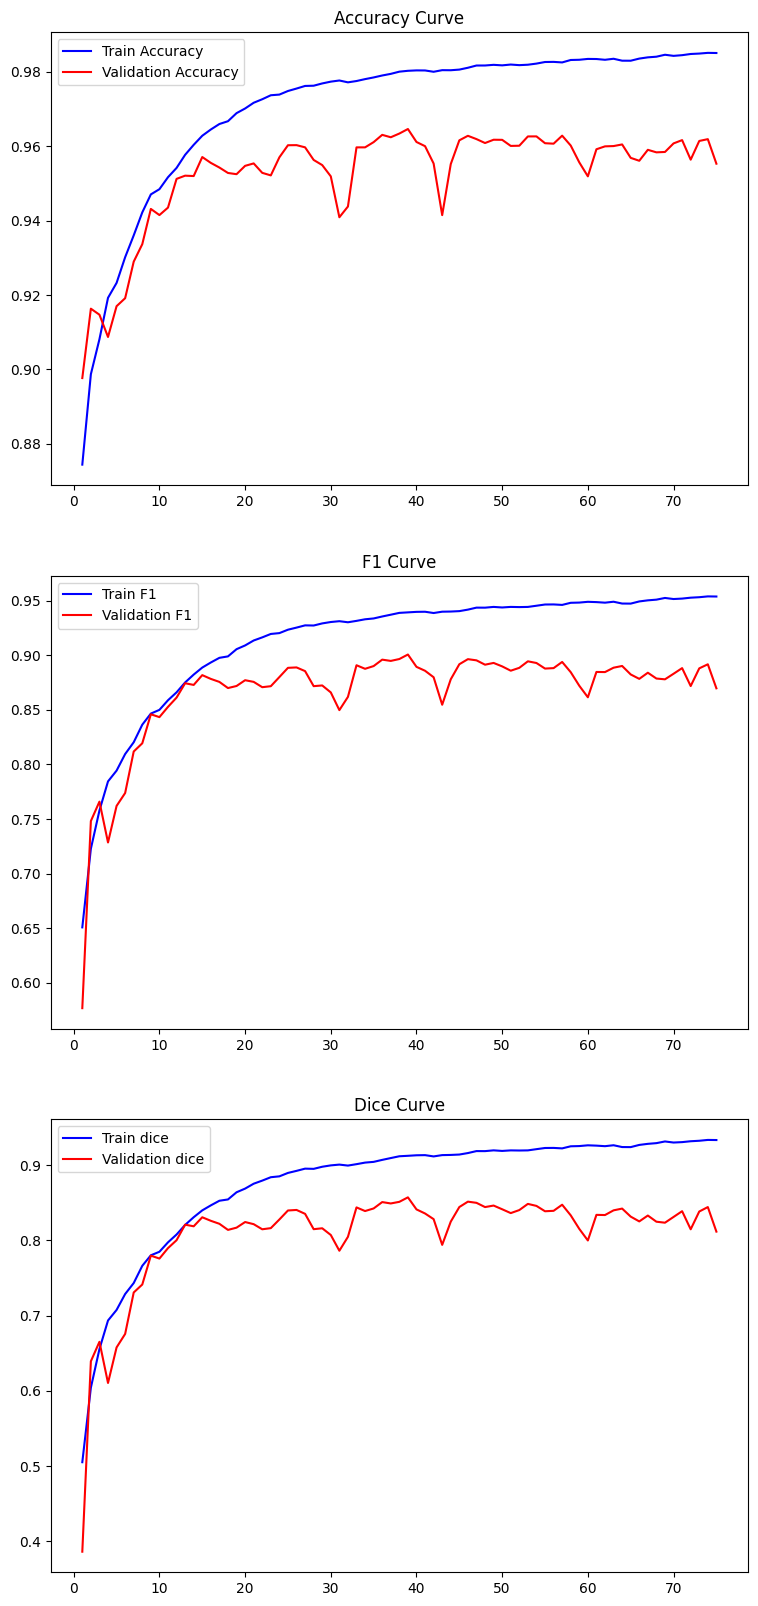

In [17]:
print(hist_fcn)
fig, ax = plt.subplots(3, 1, figsize=(9, 20))

train_epochs = [e for e, _ in hist_fcn['train_acc']]
train_acc = [v for _, v in hist_fcn['train_acc']]

val_epochs = [e for e, _ in hist_fcn['val_acc']]
val_acc = [v for _, v in hist_fcn['val_acc']]

ax[0].plot(train_epochs, train_acc, color='blue', label="Train Accuracy")
ax[0].plot(val_epochs, val_acc, color='red', label="Validation Accuracy")
ax[0].set_title("Accuracy Curve")
ax[0].legend()
#ax[0].show()



#fig, ax = plt.subplots(figsize=(9, 4.5))

train_epochs = [e for e, _ in hist_fcn['train_f1']]
train_f1 = [v for _, v in hist_fcn['train_f1']]

val_epochs = [e for e, _ in hist_fcn['val_f1']]
val_f1 = [v for _, v in hist_fcn['val_f1']]

ax[1].plot(train_epochs, train_f1, color='blue', label="Train F1")
ax[1].plot(val_epochs, val_f1, color='red', label="Validation F1")
ax[1].set_title("F1 Curve")
ax[1].legend()
#ax[1].show()


#fig, ax = plt.subplots(figsize=(9, 4.5))

train_epochs = [e for e, _ in hist_fcn['train_dice']]
train_dice = [v for _, v in hist_fcn['train_dice']]

val_epochs = [e for e, _ in hist_fcn['val_dice']]
val_dice = [v for _, v in hist_fcn['val_dice']]

ax[2].plot(train_epochs, train_dice, color='blue', label="Train dice")
ax[2].plot(val_epochs, val_dice, color='red', label="Validation dice")
ax[2].set_title("Dice Curve")
ax[2].legend()
#ax[2].show()

In [18]:
################ SAVE MODEL ########################

import os
SAVE_DIR = "./saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Stores weights + optimizer state + epoch metadata so training can resume.
checkpoint = {
    "epoch":           num_epochs,
    "model_state":     model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "num_classes":     len(classes),
    "classes":         classes,
    "hist":            hist_fcn,
}
checkpoint_path = os.path.join(SAVE_DIR, "fcn_checkpoint.pth")
torch.save(checkpoint, checkpoint_path)
print(f"Full checkpoint saved → {checkpoint_path}")

# 2. Save weights-only (for inference only)
weights_path = os.path.join(SAVE_DIR, "fcn_weights.pth")
torch.save(model.state_dict(), weights_path)
print(f"Weights-only saved   → {weights_path}")

Full checkpoint saved → ./saved_models/fcn_checkpoint.pth
Weights-only saved   → ./saved_models/fcn_weights.pth


Model loaded from './saved_models/fcn_checkpoint.pth'  (3 classes)
Classes: [0, 1, 2]
Inference complete — predicted 2565 slices.
Test  dice: 0.7948  acc: 0.9495  f1: 0.8570


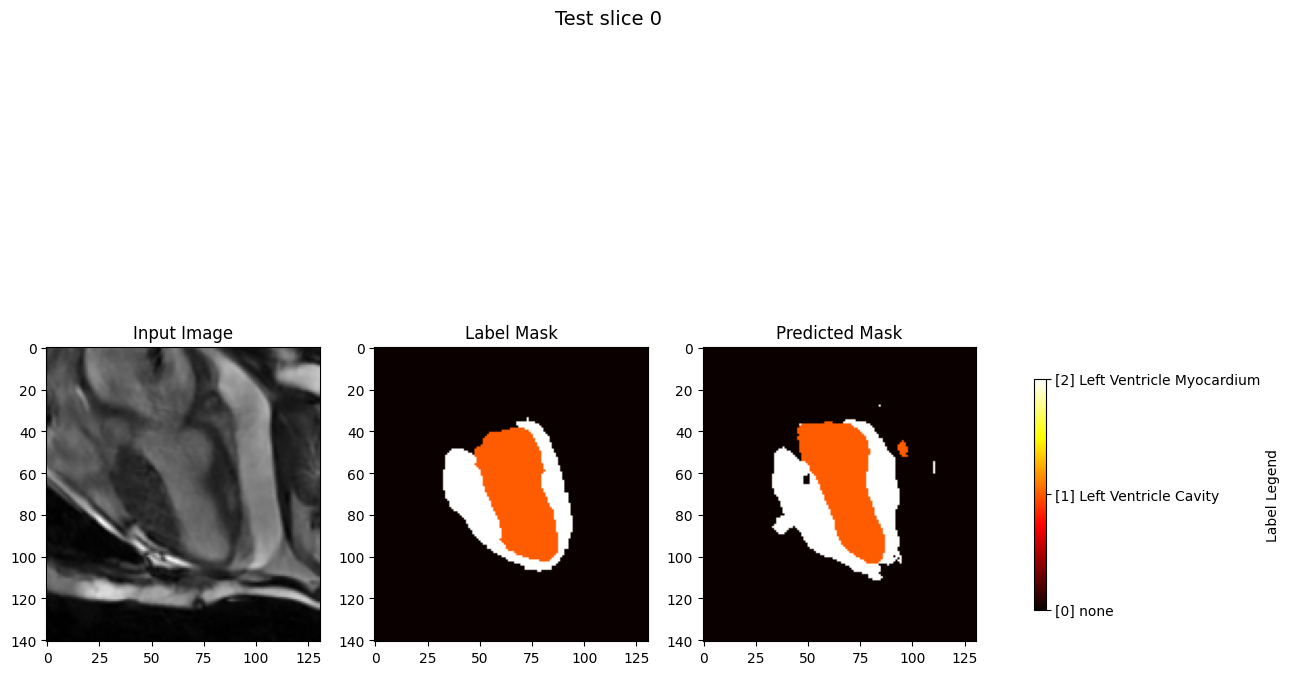

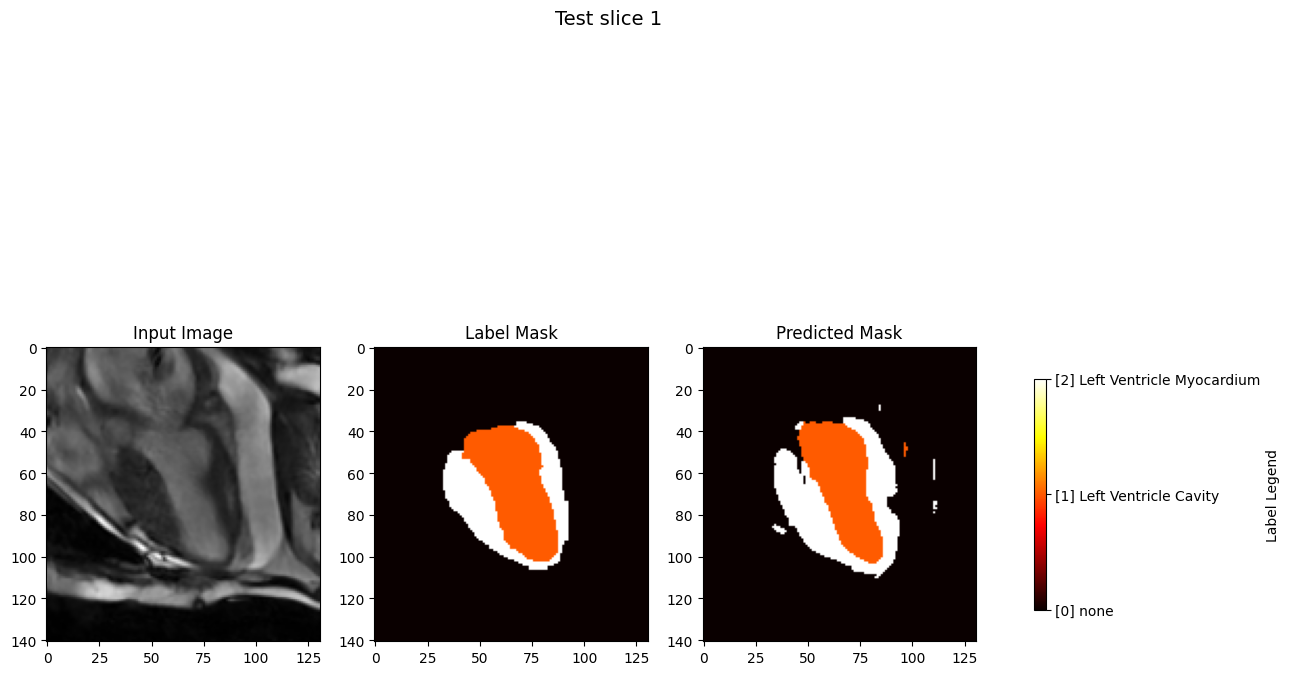

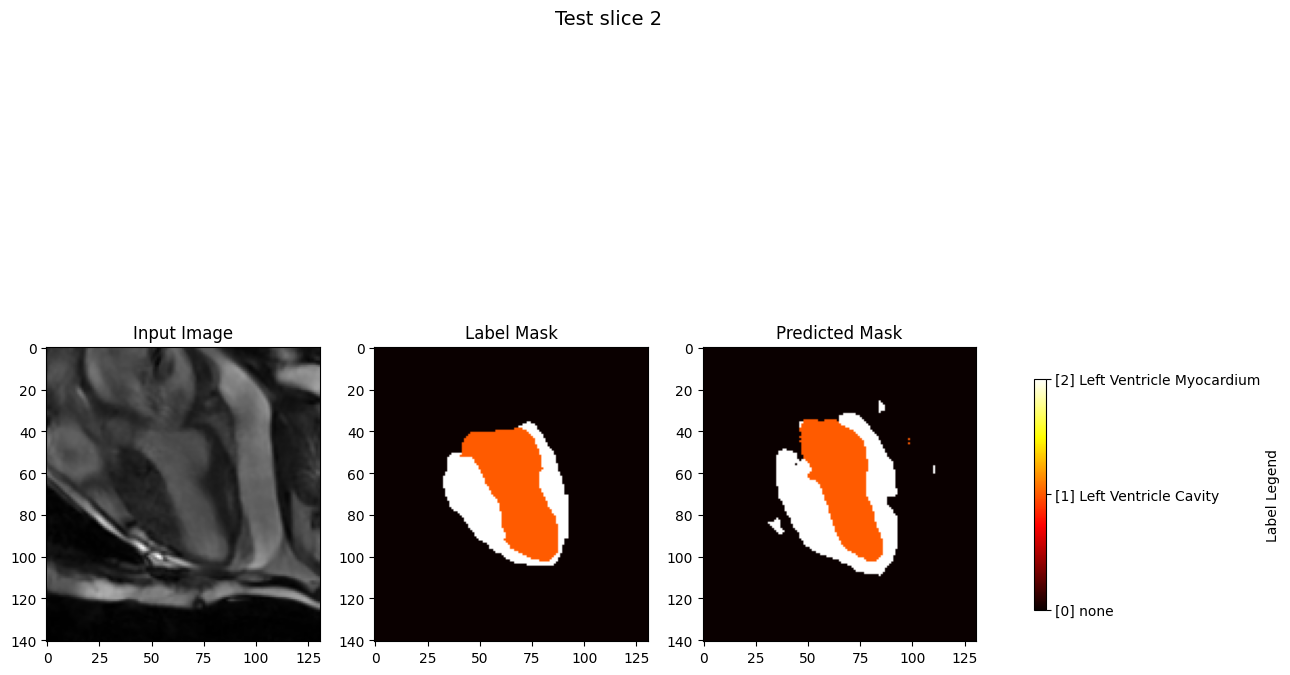

In [19]:
################################ Inference Cell
import torch
import numpy as np
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
CHECKPOINT_PATH = "./saved_models/fcn_checkpoint.pth"   # change path if needed
device = "cuda" if torch.cuda.is_available() else "cpu"

# ── 1. Restore checkpoint ─────────────────────────────────────────────────────
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

num_classes  = checkpoint["num_classes"]
classes      = checkpoint["classes"]

model_infer = FCN(in_channels=1, num_classes=num_classes).to(device)
model_infer.load_state_dict(checkpoint["model_state"])
model_infer.eval()
print(f"Model loaded from '{CHECKPOINT_PATH}'  ({num_classes} classes)")
print(f"Classes: {classes}")


# ── 2. Single-image inference helper ─────────────────────────────────────────
def predict_single(image_np, model, device):
    """
    Run segmentation on one 2-D numpy array (H, W) or (1, H, W).
    Returns a (H, W) numpy array of predicted class indices.

    Args:
        image_np : np.ndarray — raw MRI slice, already z-score normalised
                   (use the same zscaler fitted during training).
        model    : loaded FCN in eval mode.
        device   : 'cuda' or 'cpu'.
    """
    if image_np.ndim == 2:               # (H, W)  → (1, 1, H, W)
        image_np = image_np[np.newaxis, np.newaxis, ...]
    elif image_np.ndim == 3:             # (1, H, W) → (1, 1, H, W)
        image_np = image_np[np.newaxis, ...]

    tensor = torch.tensor(image_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(tensor)           # (1, C, H, W)
        pred   = torch.argmax(logits, dim=1).squeeze(0)   # (H, W)

    return pred.cpu().numpy()


# ── 3. Batch inference helper ─────────────────────────────────────────────────
def predict_dataloader(model, dataloader, device):
    """
    Run inference over an entire DataLoader.
    Returns:
        preds   : np.ndarray (N, H, W) — predicted class maps
        targets : np.ndarray (N, H, W) — ground-truth masks (or None if unavailable)
    """
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch in dataloader:
            # DataLoader may yield (image,) or (image, mask)
            if isinstance(batch, (list, tuple)) and len(batch) == 2:
                images, masks = batch
                all_targets.append(masks.squeeze(1).long().cpu().numpy())
            else:
                images = batch

            images = images.to(device)
            logits = model(images)                         # (N, C, H, W)
            preds  = torch.argmax(logits, dim=1)           # (N, H, W)
            all_preds.append(preds.cpu().numpy())

    preds_np   = np.concatenate(all_preds,   axis=0)
    targets_np = np.concatenate(all_targets, axis=0) if all_targets else None
    return preds_np, targets_np


# ── 4. Quick visual demo on the test set ─────────────────────────────────────
preds_np, targets_np = predict_dataloader(model_infer, test_mri_dataloader, device)
print(f"Inference complete — predicted {len(preds_np)} slices.")

if targets_np is not None:
    test_dice, test_acc, test_f1 = helpers.validate(
        targets_np, preds_np, num_classes=num_classes
    )
    print(f"Test  dice: {test_dice:.4f}  acc: {test_acc:.4f}  f1: {test_f1:.4f}")

# Show a few predictions
labelled_classes = helpers.load_labels(Problem_Type="CINE", Image_Type="4CH")
sample_images, sample_masks = next(iter(test_mri_dataloader))
sample_preds = preds_np[:len(sample_images)]

for i in range(min(3, len(sample_images))):
    visualize_sample(
        sample_images[i].cpu(),
        sample_masks[i].squeeze(0).cpu(),
        sample_preds[i],
        labelled_classes
    )
    plt.suptitle(f"Test slice {i}", fontsize=14)
    plt.show()
